# PageRank via Markov Chains — Monte-Carlo Simulation

This was inspired by the Veritasium video on Markov Chains
Google's search engine ranks web pages by modelling a random surfer who clicks links at random.
The long-run fraction of time the surfer spends on each page is that page's PageRank.

Mathematically this is the stationary distribution of a Markov chain whose states are web pages.

$$\pi = G\,\pi, \qquad G = d\,M + \frac{1-d}{N}\,\mathbf{1}\mathbf{1}^\top$$

| Symbol | Meaning |
|--------|--------|
| $M$ | column-stochastic link matrix (column $j$ = where page $j$'s rank flows) |
| $d\approx0.85$ | damping factor — probability of following a link |
| $1-d$ | probability of teleporting to a random page |
| $\pi$ | PageRank vector (stationary distribution) |


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import shutil

%matplotlib inline

fontsi  = 15
fontsi2 = 20

if shutil.which('latex') is not None:
    plt.rc('text', usetex=True)
    plt.rcParams['font.serif'] = ['Computer Modern']
plt.rc('font', family='serif')
plt.rcParams.update({
    'font.size':         fontsi,
    'axes.titlesize':    fontsi,
    'axes.labelsize':    fontsi2,
    'xtick.labelsize':   fontsi,
    'ytick.labelsize':   fontsi,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
    'legend.frameon':    False,
    'figure.dpi':        130,
})

## Step 1 — Define a toy web graph

We model five pages A – E connected by directed hyperlinks.
The adjacency matrix encodes which pages link to which:
`adjacency[i, j] = 1` means page $j$ has a link to page $i$.


> Exercise: try adding or removing a link and see how the PageRank changes.

In [39]:
labels = ["A", "B", "C", "D", "E"]
N = len(labels)

# adjacency[i, j] = 1  →  page j links TO page i
adjacency = np.array([
    #  A  B  C  D  E   ← source page
    [  0, 1, 1, 0, 0],  # A receives links from B, C
    [  1, 0, 0, 0, 1],  # B receives links from A, E
    [  1, 1, 0, 1, 0],  # C receives links from A, B, D
    [  0, 1, 0, 0, 1],  # D receives links from B, E
    [  0, 0, 1, 1, 0],  # E receives links from C, D
], dtype=float)

# Quick sanity check: out-degrees
for j, lab in enumerate(labels):
    out = int(adjacency[:, j].sum())
    print(f"Page {lab} links out to {out} page(s)")

Page A links out to 2 page(s)
Page B links out to 3 page(s)
Page C links out to 2 page(s)
Page D links out to 2 page(s)
Page E links out to 2 page(s)


## Step 2 — Build the column-stochastic transition matrix $M$

Each page distributes its rank equally among the pages it links to.
Dividing each column of the adjacency matrix by its sum makes the columns sum to 1 — this is the transition matrix $M$.

Dangling nodes (pages with no outgoing links) would create zero columns;
we handle them by spreading their rank uniformly across all pages.

In [40]:
col_sums = adjacency.sum(axis=0)

dangling = col_sums == 0          # pages with no outgoing links
col_sums[dangling] = 1            # avoid division by zero
M = adjacency / col_sums[np.newaxis, :]
M[:, dangling] = 1.0 / N          # dangling fix: spread rank uniformly

print("Transition matrix M (columns sum to 1):")
header = "     " + "  ".join(f"{l:>5}" for l in labels)
print(header)
for i, row_label in enumerate(labels):
    row = "  ".join(f"{M[i,j]:5.3f}" for j in range(N))
    print(f"{row_label}  [{row}]")
print("\nColumn sums:", M.sum(axis=0).round(6))

Transition matrix M (columns sum to 1):
         A      B      C      D      E
A  [0.000  0.333  0.500  0.000  0.000]
B  [0.500  0.000  0.000  0.000  0.500]
C  [0.500  0.333  0.000  0.500  0.000]
D  [0.000  0.333  0.000  0.000  0.500]
E  [0.000  0.000  0.500  0.500  0.000]

Column sums: [1. 1. 1. 1. 1.]


## Step 3 — Build the Google Matrix $G$

The plain link matrix $M$ may not be ergodic (the chain could get trapped).
Google's fix: with probability $1-d$ the surfer teleports to any page at random.
This makes every entry of $G$ positive, guaranteeing a unique stationary distribution.

$$G = d\,M + \frac{1-d}{N}\,\mathbf{1}\mathbf{1}^\top$$

In [54]:
d = 0.85   # damping factor (Google's original value)
G = d * M + (1 - d) / N * np.ones((N, N))

print(f"Damping factor d = {d}  →  teleportation probability = {1-d}")
print(f"Smallest entry in G: {G.min():.4f}  (all positive ✓)")
print(f"Column sums of G:    {G.sum(axis=0).round(6)}  (all 1 ✓)")

Damping factor d = 0.85  →  teleportation probability = 0.15000000000000002
Smallest entry in G: 0.0300  (all positive ✓)
Column sums of G:    [1. 1. 1. 1. 1.]  (all 1 ✓)


## Step 4 — Monte-Carlo simulation: the random surfer

We simulate the Markov chain directly:

1. Start on a random page.
2. At each step, sample the next page from column $G_{\cdot,\text{current}}$ of the Google Matrix.
3. Record how often each page is visited.

By the ergodic theorem, the visit frequency converges to the stationary distribution $\pi$.

In [55]:
rng = np.random.default_rng(42)

def simulate_surfer(G, n_steps=50_000):
    page = rng.integers(N)
    visits = np.zeros(N, dtype=int)
    path = [page]
    visits[page] += 1
    for _ in range(n_steps - 1):
        page = rng.choice(N, p=G[:, page])
        visits[page] += 1
        path.append(page)
    return np.array(path), visits / n_steps

surfer_path, surfer_freq = simulate_surfer(G, n_steps=50_000)

# Running average — tracks convergence step by step
running_freq = (np.cumsum(np.eye(N)[surfer_path], axis=0)
                / np.arange(1, len(surfer_path) + 1)[:, None])

print("Estimated PageRank (50 000 steps):")
for lab, r in zip(labels, surfer_freq):
    print(f"  Page {lab}: {r:.4f}")

Estimated PageRank (50 000 steps):
  Page A: 0.1856
  Page B: 0.1944
  Page C: 0.2397
  Page D: 0.1736
  Page E: 0.2067


## Step 5 — Visualise the simulation

Three panels:

| Left | Centre | Right |
|------|--------|-------|
| Surfer's path (first 200 steps) | Running visit frequency | Graph with node size ∝ simulated rank |

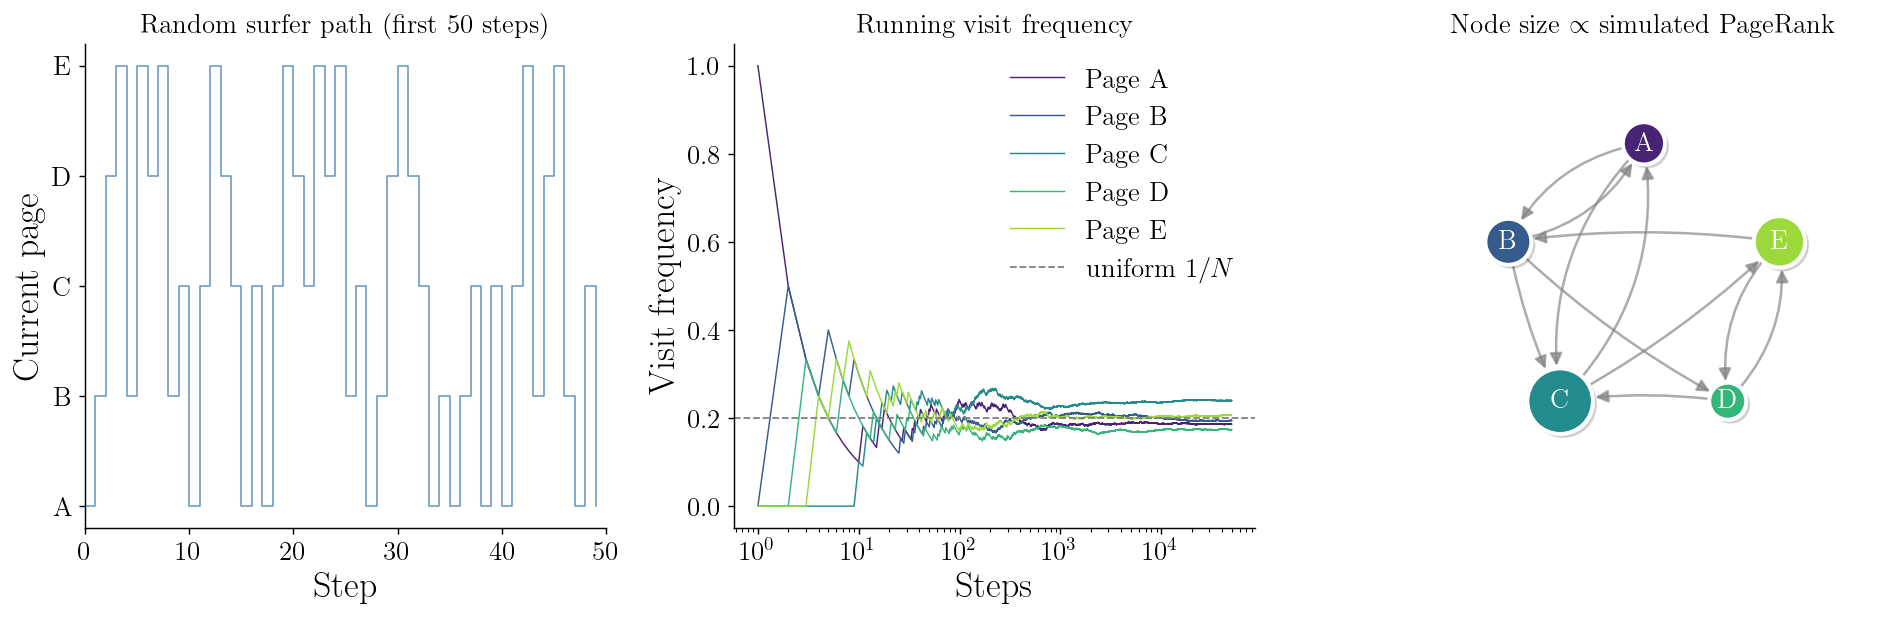

In [56]:
colors = plt.cm.viridis(np.linspace(0.1, 0.85, N))

# Node positions on a unit circle
angles = np.linspace(0, 2 * np.pi, N, endpoint=False) + np.pi / 2
positions = {i: np.array([np.cos(a), np.sin(a)]) for i, a in enumerate(angles)}

# Approximate data-units → points conversion for arrow shrink.
# Figure is 14 in wide, 3 panels, x-range 3.4 → ~85 pts per data unit.
_DATA_TO_PTS = 85

def draw_graph(ax, title, node_weights=None):
    """Draw the web graph with curved directed edges and circular nodes.

    node_weights: if given, node radii scale with these values (e.g. PageRank).
                  If None, all nodes are drawn at the same size.
    """
    ax.set_title(title, fontsize=fontsi)
    ax.set_xlim(-1.7, 1.7); ax.set_ylim(-1.7, 1.7)
    ax.set_aspect("equal"); ax.axis("off")

    # Node radii in data units
    if node_weights is None:
        radii = np.full(N, 0.18)
    else:
        w = np.array(node_weights, dtype=float)
        w_norm = (w - w.min()) / (w.max() - w.min() + 1e-9)
        radii = 0.13 + 0.10 * w_norm  # range [0.13, 0.23]

    # Edges — curve bidirectional pairs so both arrows are visible
    for j in range(N):
        for i in range(N):
            if adjacency[i, j] > 0:
                bidirectional = adjacency[j, i] > 0
                curvature = 0.25 if bidirectional else 0.07
                arrow = FancyArrowPatch(
                    tuple(positions[j]), tuple(positions[i]),
                    connectionstyle=f"arc3,rad={curvature}",
                    arrowstyle="-|>",
                    mutation_scale=14,
                    color="grey",
                    lw=1.4,
                    alpha=0.65,
                    shrinkA=radii[j] * _DATA_TO_PTS,
                    shrinkB=radii[i] * _DATA_TO_PTS,
                    zorder=1,
                )
                ax.add_patch(arrow)

    # Nodes — drop shadow + filled circle + white label
    for i, (x, y) in positions.items():
        r = radii[i]
        ax.add_patch(plt.Circle((x + 0.022, y - 0.022), r,
                                 color="black", alpha=0.13, zorder=2))
        ax.add_patch(plt.Circle((x, y), r, color=colors[i],
                                 zorder=3, ec="white", lw=2.2))
        ax.text(x, y, labels[i], ha="center", va="center",
                color="white", fontsize=fontsi, fontweight="bold", zorder=4)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Left: first 50 steps of the random walk
ax = axes[0]
ax.set_title("Random surfer path (first 50 steps)", fontsize=fontsi)
walk_len = 50
ax.plot(surfer_path[:walk_len], drawstyle="steps-post", color="steelblue", lw=0.9, alpha=0.8)
ax.set_yticks(range(N)); ax.set_yticklabels(labels, fontsize=fontsi)
ax.set_xlabel("Step", fontsize=fontsi2)
ax.set_ylabel("Current page", fontsize=fontsi2)
ax.set_xlim(0, walk_len)
ax.tick_params(labelsize=fontsi)

# Centre: running visit frequency
ax = axes[1]
ax.set_title("Running visit frequency", fontsize=fontsi)
steps = np.arange(1, len(surfer_path) + 1)
for i in range(N):
    ax.plot(steps, running_freq[:, i], color=colors[i], lw=0.8, label=f"Page {labels[i]}")
ax.axhline(1 / N, color="gray", lw=1, ls="--", label="uniform $1/N$")
ax.set_xscale("log")
ax.set_xlabel("Steps", fontsize=fontsi2)
ax.set_ylabel("Visit frequency", fontsize=fontsi2)
ax.legend(fontsize=fontsi, loc="upper right")
ax.tick_params(labelsize=fontsi)

# Right: web graph with node size ∝ simulated PageRank
draw_graph(axes[2], "Node size $\\propto$ simulated PageRank", node_weights=surfer_freq)

plt.tight_layout()
plt.savefig("pagerank_markov.pdf", bbox_inches="tight")
plt.show()

## Step 6 — How an actual search works

PageRank is computed once, offline, for the entire web. When you type a query, two more things happen:

1. Retrieval — an *inverted index* instantly returns all pages containing your query words.
2. Relevance scoring — each candidate page is scored by *TF-IDF*:

$$\text{TF-IDF}(t, d) = \underbrace{\frac{\text{count}(t,d)}{|d|}}_{\text{term frequency}} \times \underbrace{\log\frac{N+1}{|\{d': t \in d'\}|+1}}_{\text{inverse document frequency}}$$

| Symbol | Meaning |
|--------|---------|
| $t$ | a query term (word) |
| $d$ | a document (web page) |
| $\text{count}(t, d)$ | number of times $t$ appears in $d$ |
| $\|d\|$ | total number of words in $d$ |
| $N$ | total number of documents in the index |
| $\|\{d': t \in d'\}\|$ | number of documents that contain $t$ |

The IDF factor down-weights common words (e.g. "the") that appear in almost every page and carry little information.

The final ranking blends relevance with PageRank:

$$\text{score}(d, q) = (1-\alpha)\cdot\widetilde{\text{TF-IDF}}(d,q) + \alpha\cdot\widetilde{\pi}(d)$$

| Symbol | Meaning |
|--------|---------|
| $q$ | the full query string |
| $\pi(d)$ | PageRank of page $d$ (stationary distribution from the Markov chain) |
| $\widetilde{\cdot}$ | normalised to $[0,1]$ within the current result set |
| $\alpha \in [0,1]$ | trade-off: $\alpha=0$ = pure relevance, $\alpha=1$ = pure authority |

> Pages with no query words are never retrieved, no matter how high their PageRank.

In [52]:
from collections import defaultdict
import math

# Assign text content to each page
page_content = {
    "A": "Bayesian inference prior distribution statistics",
    "B": "Bayesian machine learning probabilistic model",
    "C": "machine learning neural network training optimization",
    "D": "neural network deep learning gradient descent",
    "E": "statistics probability distribution model inference statistics",
}

# Tokenise (lowercase)
tokens = {lab: page_content[lab].lower().split() for lab in labels}

# Inverted index: word → set of pages containing it
inverted_index = defaultdict(set)
for lab, words in tokens.items():
    for word in set(words):
        inverted_index[word].add(lab)

print("Page contents:")
for lab in labels:
    print(f"  {lab}: {page_content[lab]}")

print("\nInverted index (word → pages):")
for word in sorted(inverted_index):
    print(f"  '{word}': {sorted(inverted_index[word])}")

Page contents:
  A: Bayesian inference prior distribution statistics
  B: Bayesian machine learning probabilistic model
  C: machine learning neural network training optimization
  D: neural network deep learning gradient descent
  E: statistics probability distribution model inference statistics

Inverted index (word → pages):
  'bayesian': ['A', 'B']
  'deep': ['D']
  'descent': ['D']
  'distribution': ['A', 'E']
  'gradient': ['D']
  'inference': ['A', 'E']
  'learning': ['B', 'C', 'D']
  'machine': ['B', 'C']
  'model': ['B', 'E']
  'network': ['C', 'D']
  'neural': ['C', 'D']
  'optimization': ['C']
  'prior': ['A']
  'probabilistic': ['B']
  'probability': ['E']
  'statistics': ['A', 'E']
  'training': ['C']


In [57]:
def tf(word, lab):
    words = tokens[lab]
    return words.count(word) / len(words)

def idf(word):
    n_containing = len(inverted_index.get(word, set()))
    return math.log((len(labels) + 1) / (n_containing + 1) + 1)  # smoothed

def tfidf_score(query, lab):
    """Sum of TF-IDF over all query words present in the page."""
    return sum(tf(w, lab) * idf(w) for w in query.lower().split()
               if w in inverted_index)

def search(query, pagerank_scores, alpha=0.5):
    """
    Retrieve and rank pages for a query string.
      alpha = 0  →  pure TF-IDF relevance
      alpha = 1  →  pure PageRank
    """
    query_words = query.lower().split()

    # 1. Retrieval: pages containing at least one query word
    candidates = set()
    for w in query_words:
        candidates |= inverted_index.get(w, set())

    if not candidates:
        print(f'No pages found for "{query}".')
        return []

    # 2. Score each candidate
    results = [
        {"page": lab,
         "relevance": tfidf_score(query, lab),
         "pagerank":  pagerank_scores[labels.index(lab)]}
        for lab in candidates
    ]

    # 3. Normalise each component into [0, 1] within this result set
    max_rel = max(r["relevance"] for r in results) or 1
    max_pr  = max(r["pagerank"]  for r in results) or 1
    for r in results:
        r["rel_norm"] = r["relevance"] / max_rel
        r["pr_norm"]  = r["pagerank"]  / max_pr
        r["score"]    = (1 - alpha) * r["rel_norm"] + alpha * r["pr_norm"]

    return sorted(results, key=lambda r: -r["score"])


# Quick text preview
for query in ["Bayesian", "neural network", "statistics"]:
    results = search(query, surfer_freq)
    pages = " > ".join(r["page"] for r in results)
    print(f'"{query}"  →  {pages}')

"Bayesian"  →  B > A
"neural network"  →  C > D
"statistics"  →  E > A


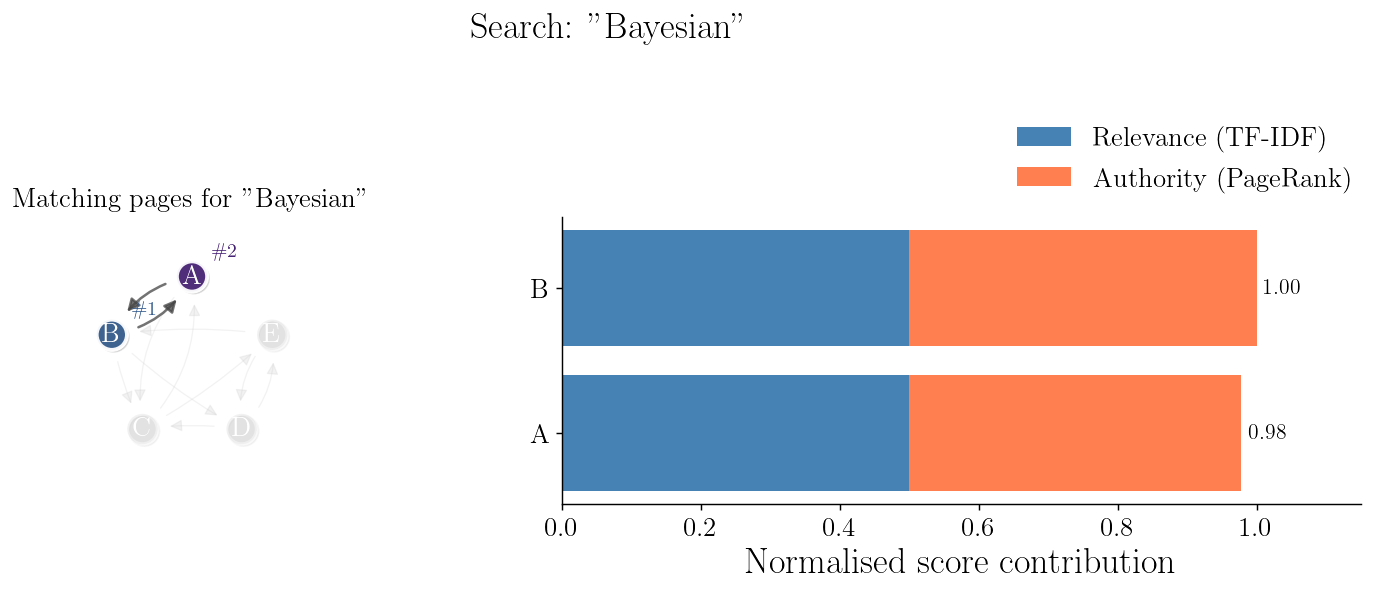

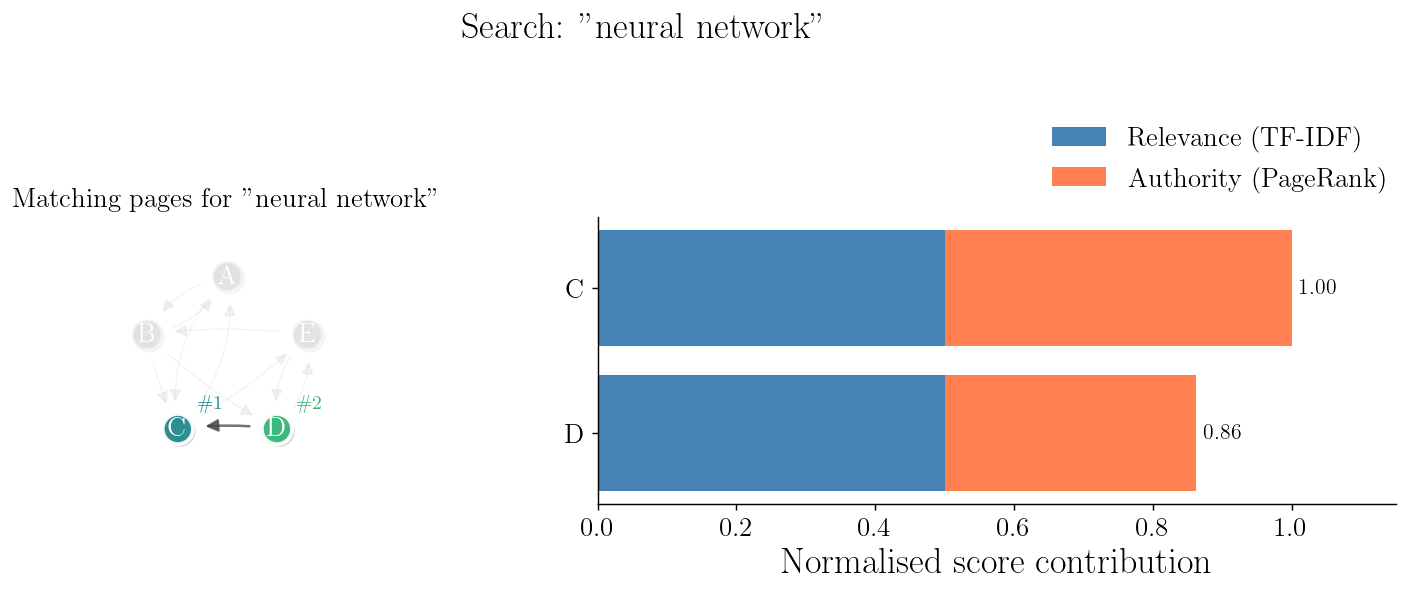

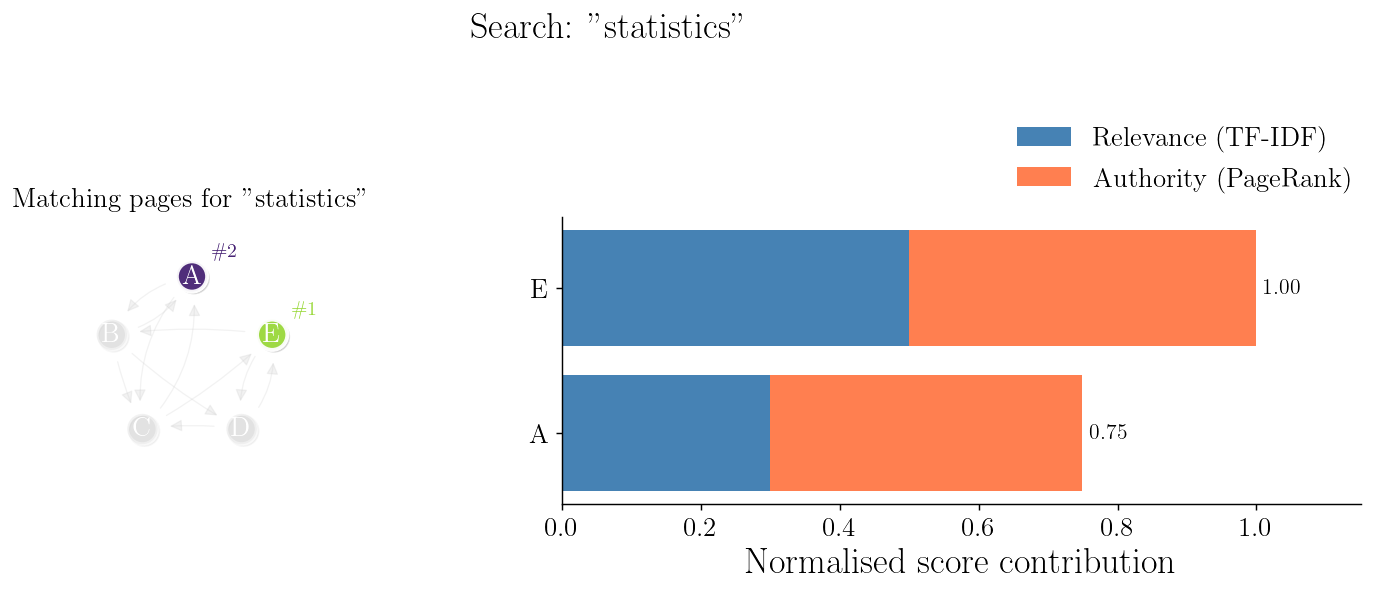

In [58]:
def show_search(query, pagerank_scores, alpha=0.5):
    results = search(query, pagerank_scores, alpha)
    if not results:
        return

    relevant = {r["page"] for r in results}
    rank_of  = {r["page"]: k + 1 for k, r in enumerate(results)}

    fig, (ax_g, ax_b) = plt.subplots(1, 2, figsize=(12, 4.5),
                                      gridspec_kw={"width_ratios": [1, 1.2]})

    ax_g.set_title(f'Matching pages for \"{query}\"', fontsize=fontsi)
    ax_g.set_xlim(-1.7, 1.7); ax_g.set_ylim(-1.7, 1.7)
    ax_g.set_aspect("equal"); ax_g.axis("off")

    for j in range(N):
        for i in range(N):
            if adjacency[i, j] > 0:
                both = labels[i] in relevant and labels[j] in relevant
                curvature = 0.25 if adjacency[j, i] > 0 else 0.07
                ax_g.add_patch(FancyArrowPatch(
                    tuple(positions[j]), tuple(positions[i]),
                    connectionstyle=f"arc3,rad={curvature}",
                    arrowstyle="-|>", mutation_scale=14,
                    color="#444444" if both else "#cccccc",
                    lw=1.4 if both else 0.7,
                    alpha=0.75 if both else 0.25,
                    shrinkA=0.18 * _DATA_TO_PTS, shrinkB=0.18 * _DATA_TO_PTS,
                    zorder=1,
                ))

    for i, (x, y) in positions.items():
        lab = labels[i]
        hit = lab in relevant
        c   = colors[i] if hit else "#cccccc"
        ax_g.add_patch(plt.Circle((x + 0.022, y - 0.022), 0.18,
                                   color="black", alpha=0.12 if hit else 0.04, zorder=2))
        ax_g.add_patch(plt.Circle((x, y), 0.18, color=c, zorder=3,
                                   ec="white", lw=2.2, alpha=0.95 if hit else 0.45))
        ax_g.text(x, y, lab, ha="center", va="center",
                  color="white", fontsize=fontsi, fontweight="bold", zorder=4)
        if hit:
            ax_g.text(x + 0.24, y + 0.24, f"\\#{rank_of[lab]}",
                      fontsize=fontsi - 4, fontweight="bold", color=colors[i], zorder=5)


    page_labs = [r["page"] for r in results]
    rel_part  = [(1 - alpha) * r["rel_norm"] for r in results]
    pr_part   = [alpha       * r["pr_norm"]  for r in results]
    scores    = [r["score"] for r in results]
    y_pos     = range(len(results))

    ax_b.barh(y_pos, rel_part, color="steelblue", label="Relevance  (TF-IDF)")
    ax_b.barh(y_pos, pr_part, left=rel_part, color="coral", label="Authority  (PageRank)")

    for k, s in enumerate(scores):
        ax_b.text(s + 0.01, k, f"{s:.2f}", va="center", fontsize=fontsi - 3)

    ax_b.set_yticks(y_pos)
    ax_b.set_yticklabels(page_labs, fontsize=fontsi)
    ax_b.invert_yaxis()
    ax_b.set_xlabel("Normalised score contribution", fontsize=fontsi2)
    ax_b.set_xlim(0, 1.15)
    ax_b.tick_params(labelsize=fontsi)
    ax_b.legend(fontsize=fontsi, loc="lower right", bbox_to_anchor=(1.02, 1))

    fig.suptitle(f'Search: \"{query}\"', fontsize=fontsi2, y=1.02)
    plt.tight_layout()
    plt.show()


show_search("Bayesian", surfer_freq, alpha=0.5)
show_search("neural network", surfer_freq, alpha=0.5)
show_search("statistics", surfer_freq, alpha=0.5)

## Summary

The random surfer is a direct Monte-Carlo simulation of the Markov chain defined by the Google Matrix $G$:

- With probability $d = 0.85$ the surfer follows a random outgoing link.
- With probability $1 - d = 0.15$ the surfer teleports to a uniformly random page.

By the ergodic theorem, the long-run visit frequency converges to the unique stationary distribution $\pi$ — which is exactly the PageRank.

### What makes a page highly ranked?
- Being linked to by many pages, or
- Being linked to by highly ranked pages (even just one).

Page C wins here because it receives links from A, B, and D — and B itself is well-connected.